# Identification
Please indicate your name

# Student: ARAFAT ISLAM



# Practical work 6 : Harris Corner Detector

The goal of this pratical work is to implement the Harris-Stephen's corners detector (C. Harris and M. Stephens. A combined corner and edge detector. In Proc. Fourth Alvey Vision Conference, pages 147–151, 1988).

Recall the Harris detector computes a map of corners from an image $I$:
$$
R(x,y) = \operatorname{det}(M) - k (\operatorname{trace}(M))^2, (x,y) \text{pixels}
$$
with $k\in[0.04, 0.06]$. $M$ is the auto-correlation of image $I$:
$$
M=\begin{pmatrix}
\sum_{x,y \in W} w(x,y)I_x^2 &
\sum_{x,y \in W} w(x,y)I_xI_y \\
\sum_{x,y \in W} w(x,y)I_xI_y &
\sum_{x,y \in W} w(x,y)I_y^2 
\end{pmatrix}
=\begin{pmatrix}
A & B \\ C & D
\end{pmatrix}
$$
with $w(x,y)=\frac1{2\pi \sigma^2}e^{\frac{(x-x_c)^2 + (y-y_c)^2}{2\sigma^2}}$ a Gaussian mask centered on the window $W$. Partial derivatives $I_x$ and $I_y$ are estimated by one of the following kernels :
- Gradient:  $G_x = \begin{pmatrix} 0 & 0 & 0\\ 1 & 0 &-1 \\ 0 & 0 & 0 \end{pmatrix}$,
 $G_y = G_x^T$
- Prewitt: $G_x = \begin{pmatrix} 1 & 0 & -1\\ 1 & 0 &-1 \\ 1 & 0 & -1 \end{pmatrix}$,
 $G_y = G_x^T$
- Sobel: $G_x = \begin{pmatrix} 1 & 0 & -1\\ 2 & 0 &-2 \\ 1 & 0 & -1 \end{pmatrix}$,
 $G_y = G_x^T$
 


In [1]:
# Load useful libraries
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal

# Useful functions 
def gaussianKernel(sigma):
    """ double -> Array
        return a gaussian kernel of standard deviation sigma
    """
    n2 = int(np.ceil(3*sigma))
    x,y = np.meshgrid(np.arange(-n2,n2+1),np.arange(-n2,n2+1))
    kern = np.exp(-(x**2+y**2)/(2*sigma*sigma))
    return  kern/kern.sum()

## Exercise 1: Harris response calculation

1) Write a function `computeR(I, scale, kappa)` that returns the Harris response $R$ from an image $I$ and a scale $scale$. You will use 5 steps:
- Computation of the directionnal derivate $I_x$ and $I_y$. Use the Sobel kernel.
- Computation of the products $I_x^2$, $I_y^2$, $I_x.I_y$.
- Computation of the convolution of $I_x^2$, $I_y^2$ and $I_x.I_y$ by a gaussian kernel of size N (use given function `gaussianKernel()`)
- Computation of $\operatorname{det}(M(x,y))$ and $\operatorname{trace}(M(x,y))$ for each pixel
- Computation of $R(x,y) = \operatorname{det}(M(x,y)) - k.(\operatorname{trace}(M(x,y)))^2$. You can use $k = 0.04$.

 You can compute the convolutions by using the ```scipy.signal.convolve2d``` function. 


In [3]:
def computeR(image, scale, kappa):
    """ Array[n, m] * float * float -> Array[n, m]
        I compute the Harris response R for each pixel of the image
    """

    # first I define the Sobel kernels because we are asked to use Sobel
    Gx = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]])

    Gy = Gx.T

    # here I compute the derivatives Ix and Iy using convolution
    # I use mode='same' to keep the same image size
    Ix = scipy.signal.convolve2d(image, Gx, mode="same", boundary="symm")
    Iy = scipy.signal.convolve2d(image, Gy, mode="same", boundary="symm")

    # then I compute the products of derivatives
    # this corresponds to Ix^2 Iy^2 and Ix*Iy
    Ix2 = Ix * Ix
    Iy2 = Iy * Iy
    Ixy = Ix * Iy

    # now I create the gaussian kernel using the given function
    # the scale parameter is used as sigma
    g = gaussianKernel(scale)

    # I smooth the derivative products with the gaussian kernel
    # this gives me the elements of the matrix M
    A = scipy.signal.convolve2d(Ix2, g, mode="same", boundary="symm")
    B = scipy.signal.convolve2d(Ixy, g, mode="same", boundary="symm")
    C = B
    D = scipy.signal.convolve2d(Iy2, g, mode="same", boundary="symm")

    # here I compute the determinant and the trace of M for each pixel
    detM = A * D - B * C
    traceM = A + D

    #  I compute the Harris response R
    R = detM - kappa * (traceM ** 2)

    return R


2) Write a script that displays the Harris response for the image ```img/house2.png``` along with the original image. Use a gaussian window of size $W=15$ pixels.

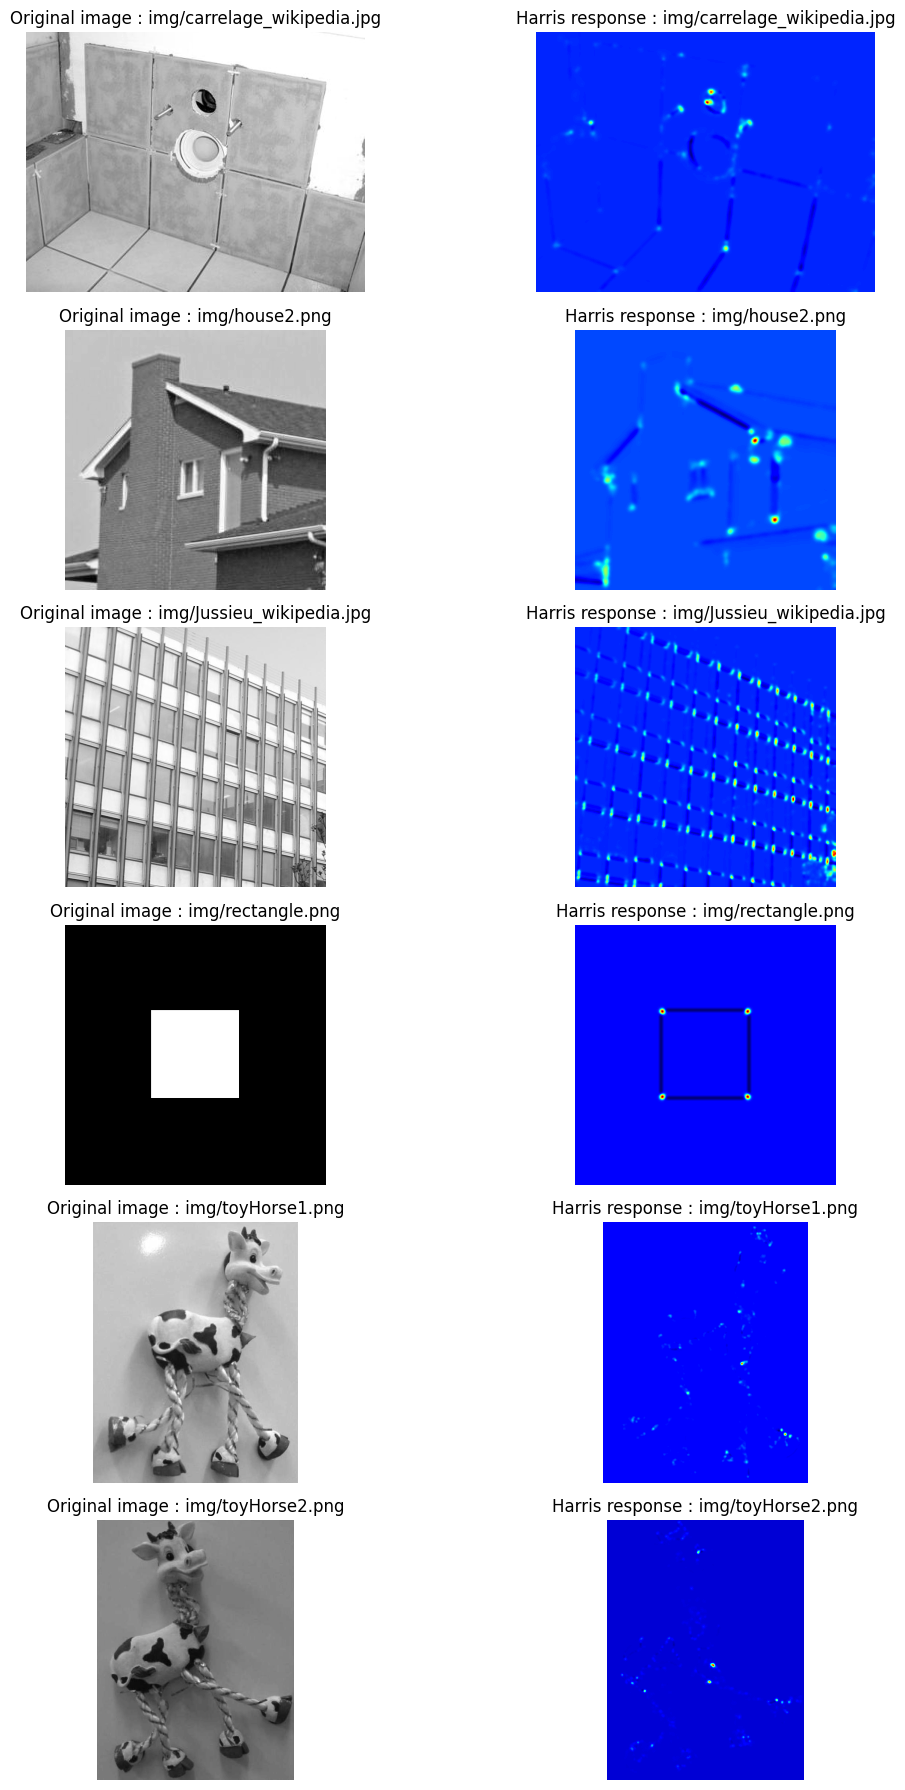

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# here I list all the image paths given in the exercise
image_paths = [
    "img/carrelage_wikipedia.jpg",
    "img/house2.png",
    "img/Jussieu_wikipedia.jpg",
    "img/rectangle.png",
    "img/toyHorse1.png",
    "img/toyHorse2.png"
]

# I set the parameters for Harris
# W = 15 pixels, so I take sigma around 15/6
sigma = 15 / 6
kappa = 0.04

# I create a figure big enough to show all results
plt.figure(figsize=(12, 18))

for i, path in enumerate(image_paths):
    # I load the image and convert it to grayscale
    img = Image.open(path).convert("L")
    img = np.array(img, dtype=float)

    # I compute the Harris response using the function from exercise 1
    R = computeR(img, sigma, kappa)

    # first subplot: original image
    plt.subplot(len(image_paths), 2, 2*i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original image : " + path)
    plt.axis("off")

    # second subplot: Harris response
    plt.subplot(len(image_paths), 2, 2*i + 2)
    plt.imshow(R, cmap="jet")
    plt.title("Harris response : " + path)
    plt.axis("off")

# I adjust the layout so that everything is readable
plt.tight_layout()
plt.show()


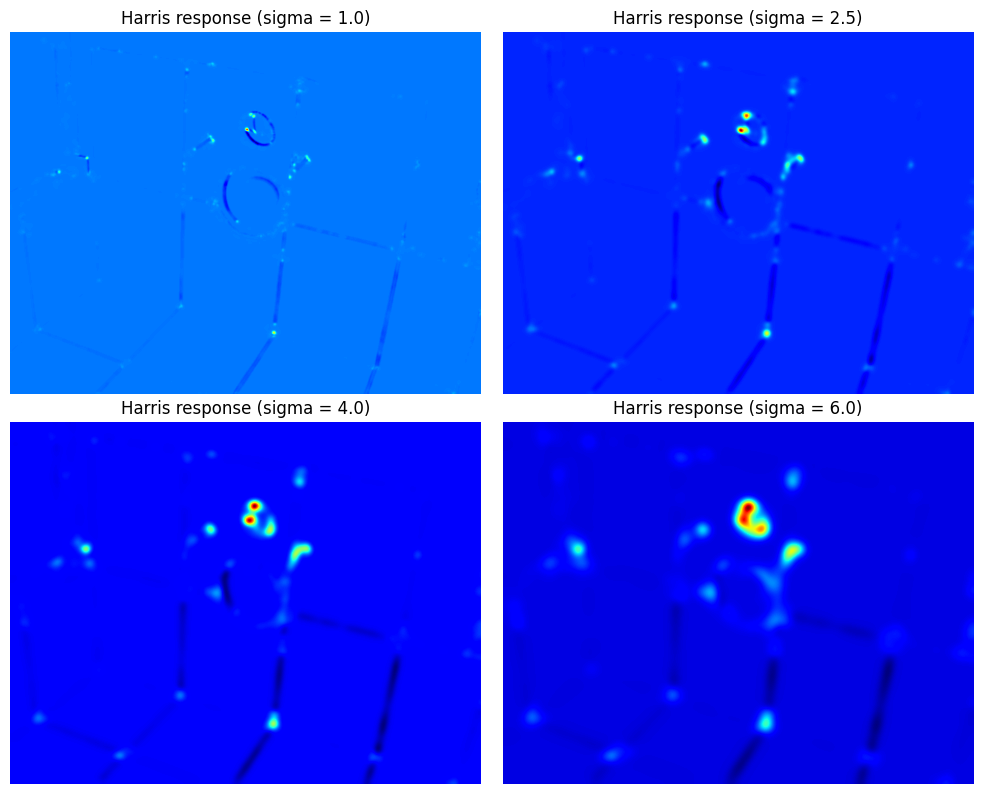

In [5]:
# I load one image to test the effect of sigma
img = Image.open("img/carrelage_wikipedia.jpg").convert("L")
img = np.array(img, dtype=float)

# I choose several sigma values to compare
sigmas = [1.0, 2.5, 4.0, 6.0]
kappa = 0.04

plt.figure(figsize=(10, 8))

for i, sigma in enumerate(sigmas):
    # I compute the Harris response for the current sigma
    R = computeR(img, sigma, kappa)

    # I display the Harris response
    plt.subplot(2, 2, i + 1)
    plt.imshow(R, cmap="jet")
    plt.title("Harris response (sigma = " + str(sigma) + ")")
    plt.axis("off")

plt.tight_layout()
plt.show()


3) Write in a few lines an interpretation of the results, explaining how the Harris response allows to detect and discriminate homogeneous areas, edges and corners.

For the first result of Harris response When I look at the Harris response images I can clearly see different behaviors depending on the type of area.
In homogeneous areas like flat walls or smooth regions the response is almost zero and appears dark blue because there is no strong intensity change in any direction.but On edges the response is weak or sometimes negative because the intensity mainly changes in one direction only.
Corners give very strong positive responses shown by bright yellow or red points because the intensity changes in both directions at the same time.
So the Harris response helps me discriminate flat regions edges and corners just by looking at the response values.

For the second result, I wanted to see the effect of the Gaussian scale, so I tested sigmas = [1, 2.5, 4, 6] on the image carrelage_wikipedia.
when sigma is 1 small value the response is very noisy and many small details appear including weak corners. When I increase sigma to 2.5 the response becomes cleaner and the main corners are easier to see. For larger sigma values like 4 and 6 the image is more smoothed and blurry so only strong and  corners can be seen but  small details disappear.

## Exercise 2 : Harris corner detector
From the Harris response calculated at exercise 1, we will write all the functions needed for the Harris detector. Write the following functions: 

1) A function `thresholdR(R, thres)` that calculates and returns the binary thresholding $R_b$ of the response $R$ according to the threshold $thres$

In [6]:
def thresholdR(R, thres):
    """ Array[n, m] * float -> Array[n, m]
    """
    # I threshold the Harris response to keep only strong values
    # I create an empty binary image with the same size as R
    Rb = np.zeros_like(R)

    # I set to 1 the pixels where the Harris response is larger than the threshold
    Rb[R > thres] = 1

    return Rb


2) A function `Rnms(R, Rbin)` that performs a non-maximum supression from the response $R$ and the binarized response $R_{bin}$. It returns the image $R_{locmax}$ (same size as $R$) =1 where $R_{bin}=1$ and the pixel has a greater value $R$ than its 8 nearest neighbors.

**Bonus**: Write a faster version of the script using Numpy function `np.roll()`.

In [8]:
def rnms(image_harris):
    """ Array[n, m] -> Array[n, m]
    """
    # I do non-maximum suppression on the Harris response.
    # I keep 1 only where the pixel is a local maximum in its 8 neighborhood.
    R = image_harris

    # I pick a simple threshold so I do not keep weak values
    # I use a fraction of the max because it is easy to tune
    thres = 0.01 * np.max(R)
    Rbin = (R > thres)

    # I start with the thresholded imagethen I will remove non maxima
    Rlocmax = Rbin.copy()

    # I compare each pixel with its 8 neighbors using shifts
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx != 0 or dy != 0:
                neighbor = np.roll(np.roll(R, dx, axis=0), dy, axis=1)
                Rlocmax = Rlocmax & (R > neighbor)

    # I convert to int so it is really 0 and 1
    return Rlocmax.astype(int)


In [9]:
def rnms_using_numpyroll(image_harris):
    """ Array[n, m] -> Array[n, m]
    """
    #I have tried to do a fast non maximum suppression using numpy rolls
    R = image_harris

    # I apply a simple threshold to remove weak responses
    thres = 0.01 * np.max(R)
    Rbin = (R > thres)

    # I start from the thresholded image
    Rlocmax = Rbin.copy()

    # I compare each pixel with its 8 neighbors
    # np.roll allows me to shift the image without loops on pixels
    shifts = [(-1, -1), (-1, 0), (-1, 1),
              (0, -1),          (0, 1),
              (1, -1),  (1, 0), (1, 1)]

    for dx, dy in shifts:
        neighbor = np.roll(np.roll(R, dx, axis=0), dy, axis=1)
        Rlocmax = Rlocmax & (R > neighbor)

    # I return a binary image with 1 for local maxima
    return Rlocmax.astype(int)


3) Write a function ``cornerDetector(image, scale, kappa, thresh)`` that returns an array of the same size as the image. The array takes two values: 1 where a corner is detected and 0 elsewhere.

In [10]:
def cornerDetector(image, sigma, kappa, thres):
    """ Array[n, m]*float*float*float -> Array[n, m]
    """
    # I return a binary image where 1 means I detect a corner
    # I compute the Harris response map first
    R = computeR(image, sigma, kappa)

    # then I threshold the response to keep only strong values
    Rbin = thresholdR(R, thres)

    # applied non-maximum suppression to keep only local maxima
    # rnms returns 1 only for pixels that are local maxima
    corners = rnms(R) * Rbin

    return corners.astype(int)


4 ) Display the detected corners on the original image for the image ```img/house2.png```. Each detected corner will be displayed as a small red disk. You can use the functions ```np.nonzero()``` and ```plt.scatter()``` to that purpose.

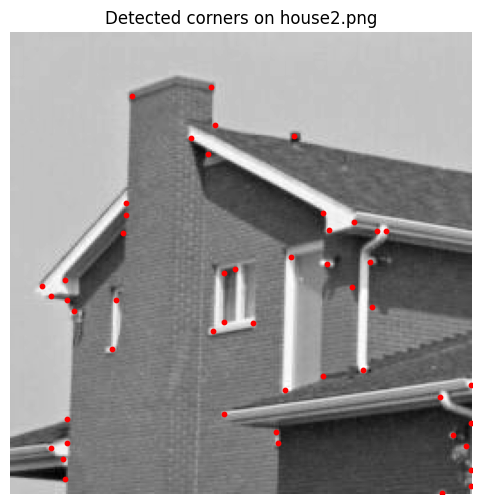

In [11]:
# I load the image and convert it to grayscale
img = Image.open("img/house2.png").convert("L")
img = np.array(img, dtype=float)

# I choose the parameters for the Harris detector
sigma = 15 / 6
kappa = 0.04
thres = 0.01 * np.max(img)

#for detecting the corners
corners = cornerDetector(img, sigma, kappa, thres)

#now need to get the coordinates of the detected corners
y, x = np.nonzero(corners)

# visualizing the original image
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Detected corners on house2.png")
plt.axis("off")

# I plot the corners as small red dots
plt.scatter(x, y, s=10, c="red")

plt.show()


5) Evaluate the performances of the corner detector. Try to find good values for Sigma and Threshold.

sigma = 1.5 , th = 0.001 , corners = 86.0
sigma = 1.5 , th = 0.005 , corners = 86.0
sigma = 1.5 , th = 0.01 , corners = 86.0
sigma = 1.5 , th = 0.1 , corners = 44.0
sigma = 2.5 , th = 0.001 , corners = 50.0
sigma = 2.5 , th = 0.005 , corners = 50.0
sigma = 2.5 , th = 0.01 , corners = 50.0
sigma = 2.5 , th = 0.1 , corners = 31.0
sigma = 4 , th = 0.001 , corners = 36.0
sigma = 4 , th = 0.005 , corners = 36.0
sigma = 4 , th = 0.01 , corners = 36.0
sigma = 4 , th = 0.1 , corners = 25.0
sigma = 5 , th = 0.001 , corners = 29.0
sigma = 5 , th = 0.005 , corners = 29.0
sigma = 5 , th = 0.01 , corners = 29.0
sigma = 5 , th = 0.1 , corners = 21.0


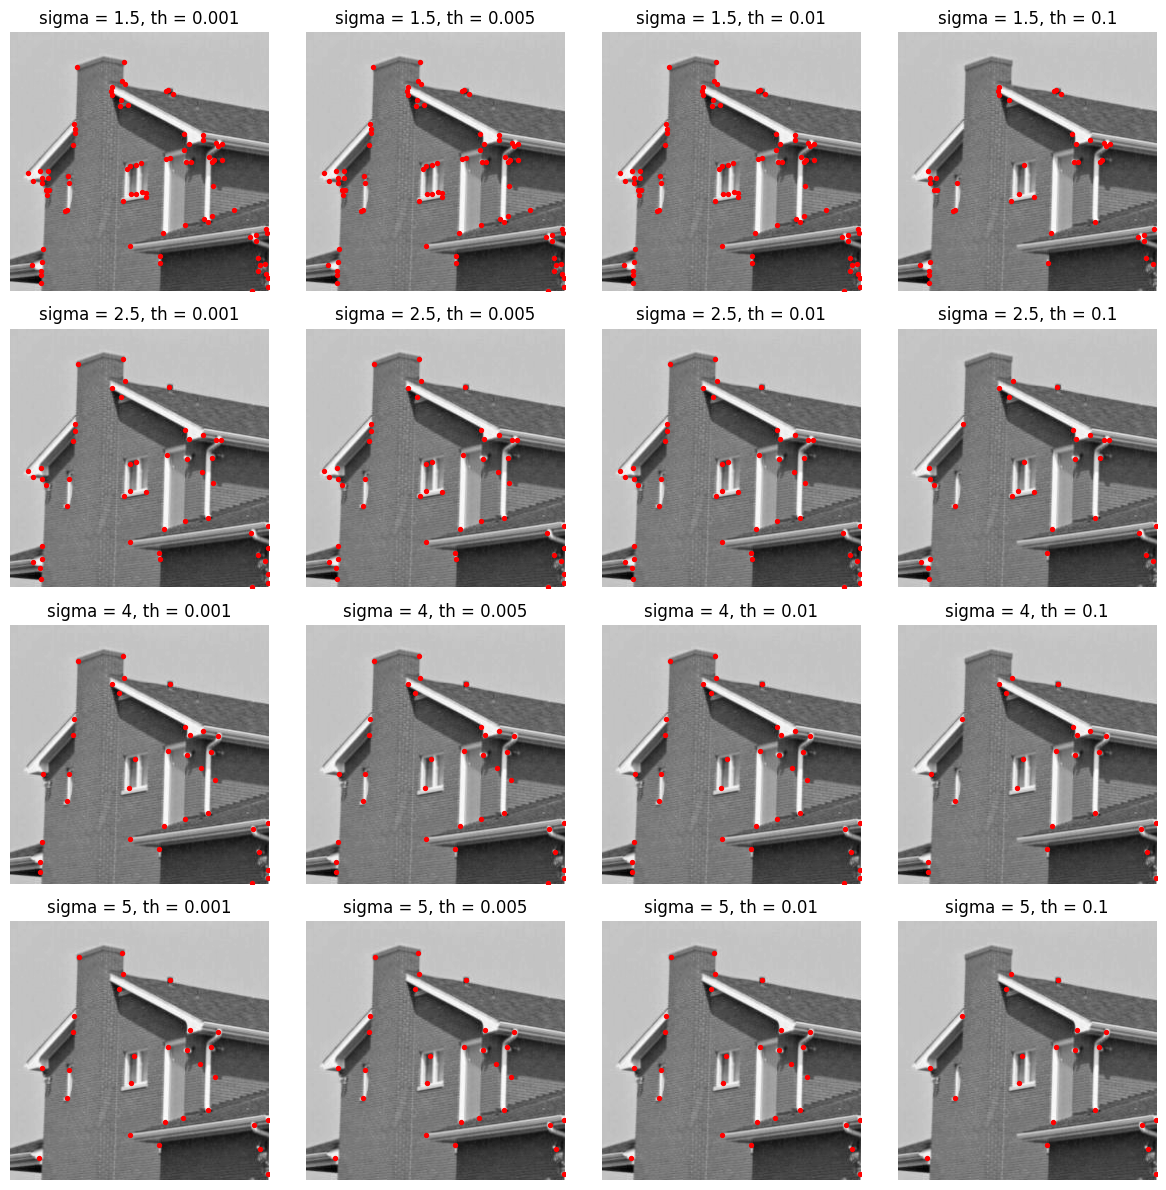

In [16]:
# I load the image
img = Image.open("img/house2.png").convert("L")
img = np.array(img, dtype=float)

# I choose different sigma and threshold values to test
sigmas = [1.5, 2.5, 4, 5]
thresholds = [0.001, 0.005, 0.01, 0.1]

kappa = 0.04

plt.figure(figsize=(12, 12))

plot_id = 1

for sigma in sigmas:
    for th in thresholds:
        # I compute the Harris response
        R = computeR(img, sigma, kappa)

        # I apply threshold and non-maximum suppression
        Rbin = thresholdR(R, th * np.max(R))
        corners = rnms(R) * Rbin
        # I wanna see how many corners fo each combination of sigma and threshold has
        nb_corners = np.sum(corners)
        print("sigma =", sigma, ", th =", th, ", corners =", nb_corners)

        # I get corner coordinates
        y, x = np.nonzero(corners)

        # I plot the result
        plt.subplot(len(sigmas), len(thresholds), plot_id)
        plt.imshow(img, cmap="gray")
        plt.scatter(x, y, s=8, c="red")
        plt.title("sigma = " + str(sigma) + ", th = " + str(th))
        plt.axis("off")

        plot_id += 1

plt.tight_layout()
plt.show()


When I look at the results I can see that sigma has a big effect on the number and quality of detected corners. like For small sigma like 1.5, 86  corners are detected (I have printed teh number of corner) but visually in the image some of them are noisy and not always seen. This means the detector is very sensitive to small details and texture. When I increase sigma to 2.5 the number of corners drops to around 50. and most detected corners correspond to real structural points like roof edges and window corners and this result looks cleaner.For larger sigma values like 4 and 5 the number of corners keeps decreasing. The detector becomes more selective and only keeps strong corners but some useful details and other corners are lost. The threshold mainly controls how many weak responses are removed. For thresholds 0.001, 0.005 and 0.01 the number of corners stays the same which means these thresholds are too low to remove additional points. When the threshold is increased to 0.1 the number of corners clearly decreases and only the strongest corners were in the image visualization and in the calculations. From both the visual results and the number of detected corners a good combination seems to me is the sigma around 2.5 or 4 with a threshold around 0.01. This gives a good number of corners that are well localized on meaningful structures without too much noise or losing important points.

## Exercise 3 : Properties of Harris corner detector

The goal of this exercice is to study some invariance properties of Harris detector.

1) Write a script that detects the corners on the images ```img/toyHorse1.png``` and ```img/toyHorse2.png``` with a scale of 15 and appropriate threshold value. Display the detected corners on the images.

toyHorse1 : sigma = 15 , th = 0.001 , corners = 22
toyHorse1 : sigma = 15 , th = 0.005 , corners = 22
toyHorse1 : sigma = 15 , th = 0.01 , corners = 22
toyHorse1 : sigma = 15 , th = 0.05 , corners = 22
toyHorse1 : sigma = 15 , th = 0.1 , corners = 21
toyHorse1 : sigma = 15 , th = 0.2 , corners = 15
toyHorse2 : sigma = 15 , th = 0.001 , corners = 21
toyHorse2 : sigma = 15 , th = 0.005 , corners = 21
toyHorse2 : sigma = 15 , th = 0.01 , corners = 21
toyHorse2 : sigma = 15 , th = 0.05 , corners = 20
toyHorse2 : sigma = 15 , th = 0.1 , corners = 19
toyHorse2 : sigma = 15 , th = 0.2 , corners = 17


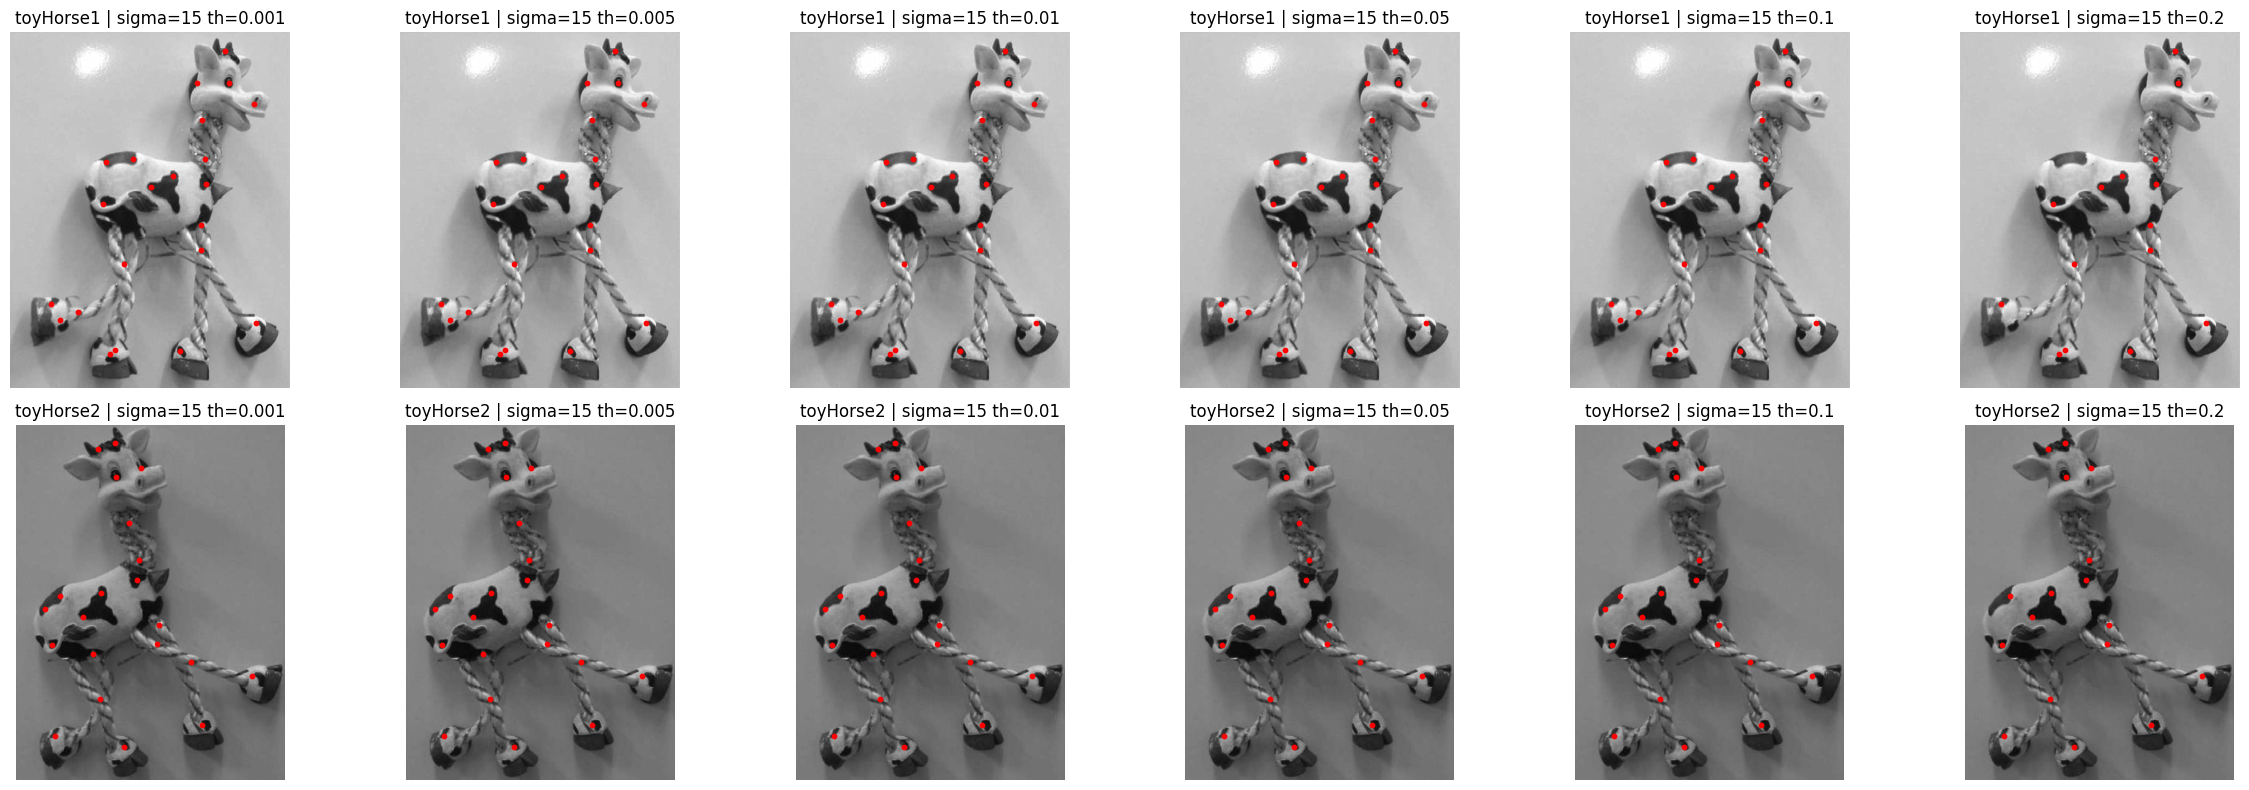

In [17]:
# I have loaded the two toy horse images in grayscale
img1 = Image.open("img/toyHorse1.png").convert("L")
img2 = Image.open("img/toyHorse2.png").convert("L")

img1 = np.array(img1, dtype=float)
img2 = np.array(img2, dtype=float)

# the exercise asks for a scale of 15 so I use sigma = 15
sigma = 15
kappa = 0.04

# I try several thresholds to see which one gives a clean set of corners
# I will use them as a fraction of max(R) for each image
thresholds = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2]

images = [("toyHorse1", img1), ("toyHorse2", img2)]

plt.figure(figsize=(4 * len(thresholds), 8))

for row_id, (name, img) in enumerate(images):
    # I compute the Harris response once, because I reuse it for all thresholds
    R = computeR(img, sigma, kappa)
    Rmax = np.max(R)

    for col_id, th in enumerate(thresholds):
        thres_value = th * Rmax

        # I detect corners for this threshold
        corners = cornerDetector(img, sigma, kappa, thres_value)

        # I count how many corners I get
        nb_corners = int(np.sum(corners))
        print(name, ": sigma =", sigma, ", th =", th, ", corners =", nb_corners)

        # I plot the image and overlay corners as red dots
        y, x = np.nonzero(corners)

        plt.subplot(2, len(thresholds), row_id * len(thresholds) + col_id + 1)
        plt.imshow(img, cmap="gray")
        plt.scatter(x, y, s=10, c="red")
        plt.title(name + " | sigma=" + str(sigma) + " th=" + str(th))
        plt.axis("off")

plt.tight_layout()
plt.show()


When I look at the results for toyHorse1 and toyHorse2 I can see that the Harris detector behaves quite similarly on both images.
For small threshold values of 0.001 to 0.01 the number of detected corners stays almost the same. This means these thresholds are low enough to keep all meaningful corners and do not remove weak ones yet.But When I increase the threshold to 0.05 and higher the number of corners slowly decreases. Only the strongest corners remain and some weaker ones disappear. This is visible on the images where fewer red points are shown.

Even though the two images are not exactly the same they give a very close number of corners. This shows that the Harris detector is quite stable to small changes in viewpoint and pose at this scale.Overall to me using sigma = 15 and a threshold around 0.01 or 0.05 seems to be a good compromise to detect consistent and meaningful corners on both images.

2) What are the dynamic ranges of these two images ?

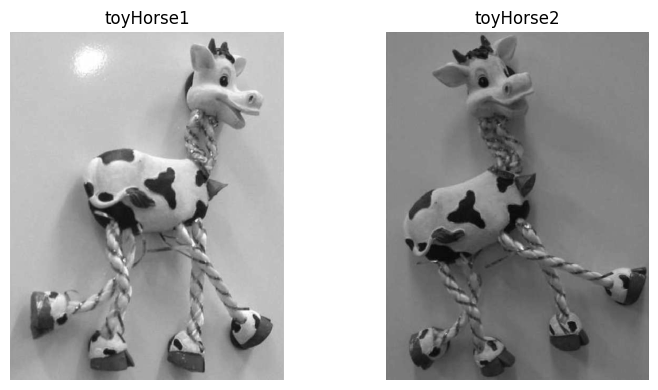

For toyHorse1 image: 
I check the pixel type and I get m = 8 bits
Using the lecture formula (Lecture 1, page 39), I compute L = 2^m = 256
So the theoretical range is k in [0, 255 ]
I have checked the real min and max in the image:
k_min = 1
k_max = 255
So the dynamic range is [ 1 , 255 ]
And the range width is 254

For toyHorse2 image: 
I check the pixel type and I get m = 8 bits
Using the lecture formula (Lecture 1, page 39), I compute L = 2^m = 256
So the theoretical range is k in [0, 255 ]
I have checked the real min and max in the image:
k_min = 0
k_max = 253
So the dynamic range is [ 0 , 253 ]
And the range width is 253



In [19]:
# I load the two images in grayscale
img1_path = "img/toyHorse1.png"
img2_path = "img/toyHorse2.png"

img1 = np.array(Image.open(img1_path).convert("L"))
img2 = np.array(Image.open(img2_path).convert("L"))

# I show the two images side by side so I know what I am working with
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap="gray")
plt.title("toyHorse1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap="gray")
plt.title("toyHorse2")
plt.axis("off")

plt.tight_layout()
plt.show()

# Now I calculate the dynamic range using the idea from the lecture
# From Lecture 1: introduction and basics, page 39:
# L = 2^m and k in [0, ..., 2^m - 1]
# Here m is the number of bits per pixel.

def dynamic_range_info(img, name):
    # I get min and max intensities actually present in the image
    k_min = int(img.min())
    k_max = int(img.max())

    # I estimate m using the dtype (uint8 means 8 bits)
    m = img.dtype.itemsize * 8

    # theoretical number of gray levels from the lecture formula
    L = 2 ** m

    print("For", name, "image: ")
    print("I check the pixel type and I get m =", m, "bits")
    print("Using the lecture formula (Lecture 1, page 39), I compute L = 2^m =", L)
    print("So the theoretical range is k in [0,", L - 1, "]")
    print("I have checked the real min and max in the image:")
    print("k_min =", k_min)
    print("k_max =", k_max)
    print("So the dynamic range is [", k_min, ",", k_max, "]")
    print("And the range width is", k_max - k_min)
    print()

dynamic_range_info(img1, "toyHorse1")
dynamic_range_info(img2, "toyHorse2")


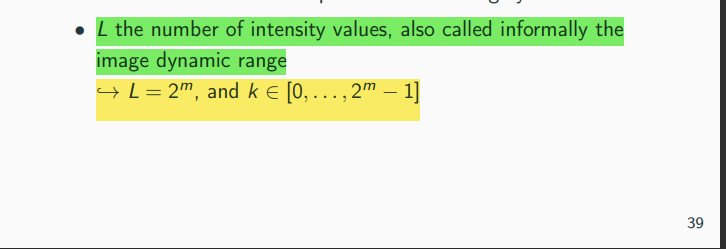

3) What are the transformations beetween the two images ?

toyHorse1 mean intensity = 166.47176838599333
toyHorse2 mean intensity = 111.72060012286998

toyHorse1 intensity std = 43.145676739013446
toyHorse2 intensity std = 30.569861264476994


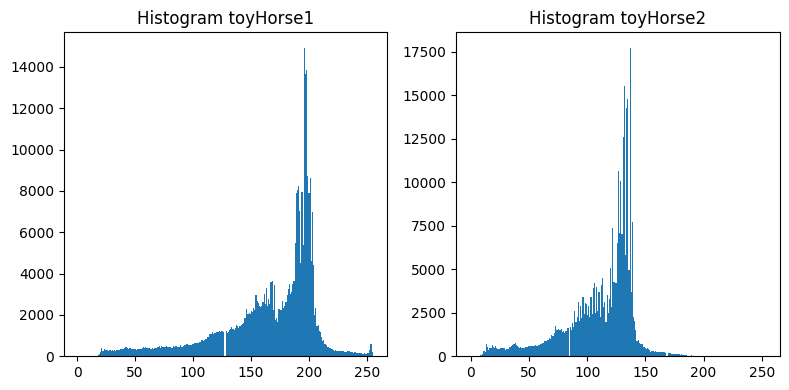

Estimated translation (x, y): [-87.35064935  -2.82467532]


In [24]:
# I compute basic statistics
mean1 = img1.mean()
mean2 = img2.mean()

std1 = img1.std()
std2 = img2.std()

print("toyHorse1 mean intensity =", mean1)
print("toyHorse2 mean intensity =", mean2)
print()
print("toyHorse1 intensity std =", std1)
print("toyHorse2 intensity std =", std2)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.hist(img1.flatten(), bins=256)
plt.title("Histogram toyHorse1")

plt.subplot(1,2,2)
plt.hist(img2.flatten(), bins=256)
plt.title("Histogram toyHorse2")

plt.tight_layout()
plt.show()


# I choose parameters like i did in previous exercise
sigma = 15
kappa = 0.04
thres = 0.01 * np.max(computeR(img1, sigma, kappa))

# I compute the corner maps
corners1 = cornerDetector(img1, sigma, kappa, thres)
corners2 = cornerDetector(img2, sigma, kappa, thres)


y1, x1 = np.nonzero(corners1)
y2, x2 = np.nonzero(corners2)

center1 = np.array([x1.mean(), y1.mean()])
center2 = np.array([x2.mean(), y2.mean()])

translation = center2 - center1

print("Estimated translation (x, y):", translation)



Visually the two images show the same toy horse but in a different position and orientation and hoyhorse 1 is brighter than the image of toyhorse 2. The toy in toyHorse2 is slightly rotated compared to toyHorse1and it is also shifted in the image. I do not see change in size so there is no strong scale transformation.
Then I used code to check different transformations between the two images. at FirstI checked brightness and contrast by computing the mean intensity and the standard deviation. I got a higher mean and standard deviation for toyHorse1, which means it is brighter and has higher contrast than toyHorse2. The histograms also show that toyHorse2 is darker and has a narrower intensity distribution. Then I checked translation using Harris corners. I computed the average position of the detected corners and found an estimated translation of about -87, -3 pixels. This means toyHorse2 is mainly shifted to the left compared to toyHorse1. so basically by visually comparing the images and the corner distributions I can see a small rotation between the two images.

4) Using a fixed threshold, is the detection invariant to rotation ? To affine transformation of brightness ?

Using a fixed threshold the Harris detector is almost invariant to rotation but it is not invariant to brightness changes.

From the previous exercises with toyHorse1 and toyHorse2 I saw that even if the object is rotated most corners are still detected at similar locations. This means that rotation does not really affect the detection, because corners stay corners after rotation.but when I looked at the brightness and contrast differences between the two images the Harris responses were not exactly the same. as I used a fixed threshold some corners disappeared when the image was darker or i can say had lower contrast. This shows that Harris detection depends on image intensity values.so, based on the results I got before the Harris detector is robust to rotation but it is not invariant to affine brightness transformations when the threshold is fixed.
